In [ ]:
import jax
from jax import lax
from jax import Array
import jax.numpy as jnp
from jax.scipy.special import xlogy
jax.config.update('jax_enable_x64', True)
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy
from itertools import product as iproduct
from scipy.linalg import expm
from time import perf_counter
from functools import partial


GraphT = tuple[Array, Array, Array]

### MPL Config

In [61]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 150,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Helvetica",
})


### Utils

In [62]:
# ---- entropy and KL divergence use convention that 0 log 0 = 0
# TODO make custom vjp since both branches can participate in autodiff tracing, which is unpleasant
# (see jax xlogy vjp)
def H(p, axis=None):
  return - jnp.sum(jnp.where(p != 0., xlogy(p, p), jnp.zeros_like(p)), axis=axis)

def KL(p, q, axis=None):
  return jnp.sum(jnp.where(p != 0., xlogy(p, p) - xlogy(p,q), jnp.zeros_like(p)), axis=axis)

def KL2(p, q, axis=None):
  p_ok = p != 0.
  return jnp.sum(jnp.where(p_ok, lax.mul(p, lax.log(p)) - lax.mul(p, lax.log(q)), jnp.zeros_like(p)), axis=axis)

### Ising Model

In [ ]:
# ---- Periodic boundaries ----
# def neighbors(i, L):
#     r, c = divmod(i, L)
#     return [((r-1)%L)*L + c, ((r+1)%L)*L + c,
#             r*L + (c-1)%L,   r*L + (c+1)%L]

# ---- Empty boundaries ----
def neighbors(i: int, L: int) -> list[int]:
  r, c = divmod(i, L)
  nbrs = []
  if r > 0:       nbrs.append((r-1)*L + c)   # up
  if r < L-1:     nbrs.append((r+1)*L + c)   # down
  if c > 0:       nbrs.append(r*L + (c-1))   # left
  if c < L-1:     nbrs.append(r*L + (c+1))   # right
  return nbrs

# ---- get all neighbors ----
def compute_site_neighbors(L: int):
  return [neighbors(i, L) for i in range(L * L)]


In [ ]:
def dense_generator_from_rates(rows: Array, rates: Array):
  N, n_states = rates.shape

  cols = jnp.arange(n_states)

  K = jnp.zeros((n_states, n_states), dtype=rates.dtype)

  K = K.at[
    rows.reshape(-1), 
    jnp.tile(cols, N),
  ].add(rates.reshape(-1))

  # on diagonal, so cols sum to zero
  K = K.at[cols, cols].add(-rates.sum(axis=0))
  return K

# ---- for Glauber using G ----
@jax.jit
def apply_glauber_transition(p: Array, graph: GraphT, beta, h, J=1.0):
  rows, dE_J, dE_h_sign = graph
  N = rows.shape[0]
  dE = J * dE_J + h * dE_h_sign

  # flip probability
  # off = jnp.exp(-beta * jnp.maximum(dE, 0.0)) / N
  flip_prob = jax.nn.sigmoid(-beta * dE) / N

  # prob of remaining in original state
  diag = 1.0 - flip_prob.sum(axis=0)

  p_next = diag * p
  
  def body(site, res):
    # rows[site, sigma] is sigma with site flipped. 
    # => rows[site] is all possible states with flipped at `site`
    #     - this is also the index of the state with this flipped site, which is used to get energy
    incoming = (flip_prob[site] * p)[rows[site]]
    return res + incoming
  
  # row -> index of state with site i flipped
  # col -> index of sigma
  # G[row, col] = G[sigma^i, sigma] = prob of going from sigma to sigma^i
  # go through flipping each of N sites
  return lax.fori_loop(0, N, body, p_next)


# ── Propagator and time evolution ─────────────
def make_propagator(K):
  def propagator(t):
    return expm(K * t)
  return propagator


### Graph Topology

In [ ]:
def make_interaction_graph(shape: tuple[int, int]) -> GraphT:
  r""" only dependent on topology, no params """
  # build on host, output jax arrays
  Lx, Ly = shape
  N = Lx * Ly
  nstates = 1 << N


  # - each amsk has exactly one bit set, corresponding to the lattice site
  # - last element of the array is 1<<0, so it is flipping the first bit
  masks = np.array([1 << (N - 1 - site) for site in range(N)], dtype=np.int64)

  # ^ XOR --> σ^mask flips the bit at the site
  # rows[site, σ] = σ ^ masks[site] --> states flipped at each site, which is the index of the flipped state
  # shape (N, 2^N)
  rows = [np.arange(nstates, dtype=np.int64) ^ mask for mask in masks]

  # get the neighbors for each site - list of lists
  site_neighbors = compute_site_neighbors(Lx)

  # enumerate all 2^N states
  states = np.arange(nstates, dtype=np.int64)
  # convert binary bits to spins - shape (N, 2^N)
  # states[None, :] & masks[:, None] -> gives a bitstring with 0 offsite and either 1 or 0 on site
  # --> each element here is an integer of the form 2^site or 0. If the element is a zero, it thus
  # means that this boolean operation converted the whole bitstring to zeros since it was zero at
  # the site bit. Otherwise, if !=0, then it is of form 2^site and had a 1 at that site
  #
  # spins thus gives the spin value at each site of N sites for all 2^N states, resulting in an
  # array of size (N, 2^N)
  spins = np.where((states[None, :] & masks[:, None]) != 0, 1.0, -1.0)
  # alternatively,
  # spins = np.where((np.array(rows) & masks[:, None]) == 0, 1.0, -1.0)

  # neighbor sum
  nb_sum = np.zeros((N, nstates), dtype=np.float32)
  for site in range(N):
    for j in site_neighbors[site]:
      nb_sum[site] += spins[j]

  # should have no numerical issues here since spins are +1, -1 and |nb_sum| <= #neighbors
  # ferromagnetic interaction part
  dE_J = 2.0 * spins * nb_sum
  # external magnetic field interaction part
  dE_h_sign = 2.0 * spins
  # convert to JAX
  return (
    jnp.array(rows, dtype=jnp.int64), 
    jnp.array(dE_J, dtype=jnp.float32), 
    jnp.array(dE_h_sign, dtype=jnp.float32)
  )

### Rates

In [ ]:
def get_rates(graph: GraphT, J: float, h: float, betas: Array, gammas: Array):
  r""" 
  betas,   # shape (n_baths,)
  gammas,  # shape (n_baths,)
  """
  _, dE_J, dE_h_sign = graph
  # shape: (N, nstates)
  dE = J * dE_J + h * dE_h_sign

  # Bath-resolved rates:
  #     rates_nu[nu, i, sigma] = rate for sigma -> sigma^i through bath nu
  # Total rate after summing physical channels
  # shape: (N, nstates)
  # rates_nu = gammas[:, None, None] * jnp.exp(-0.5 * betas[:, None, None] * dE[None, :, :])
  rates_nu = gammas[:, None, None] * jax.nn.sigmoid(-betas[:, None, None] * dE[None, :, :])
  return rates_nu

def apply_K_from_rates(p: Array, rows: Array, rates: Array):
  r"""
  Compute K @ p without constructing K.

  rows[i, sigma] = configuration sigma with spin i flipped
  rates[i, sigma] = rate sigma -> sigma^i

  d/dt p_σ =Σ_i[k_i(σ^i)p_{σ^i} - k_i(σ)p_σ].
  """
  # flux is probability/time, but, as opposed to current, it is a one-way, directed flow rate

  # Outgoing flux from each source configuration:
  #     flux[i, sigma] = rate(sigma -> sigma^i) p[sigma]
  flux = rates * p[None, :]

  # diagonal / escape contribution
  outgoing = flux.sum(axis=0)

  # add flux to destination states -> incoming contribution
  incoming = jnp.take_along_axis(flux, rows, axis=1).sum(axis=0)
  # incoming = jnp.zeros_like(p).at[rows.reshape(-1)].add(
  #   flux.reshape(-1)
  # )

  return incoming - outgoing

def apply_P_from_rates(p, rows, rates, lam):
  # P[sigma^i, sigma] = rate_i(sigma) / lam
  flip_prob = rates / lam

  # diagonal of P
  diag = 1.0 - flip_prob.sum(axis=0)

  # outgoing flux associated with each possible flip
  flux = flip_prob * p[None, :]

  # Because spin flipping is an involution:
  # rows[i, sigma] gives the source for incoming
  # probability into sigma through site i.
  incoming = jnp.take_along_axis(flux, rows, axis=1).sum(axis=0)

  return diag * p + incoming

@jax.jit
def apply_K(p, graph, J, h, betas, gammas):
  rates = get_rates(graph, J, h, betas, gammas).sum(axis=0)
  return apply_K_from_rates(p, graph[0], rates)

@partial(jax.jit, static_argnames=("n_terms", "use_glauber"))
def _propagate_ctmc(p0: Array, t, graph: GraphT, J, h, betas, gammas, n_terms=64, use_glauber: bool=False):
  rows, dE_J, dE_h_sign = graph
  if use_glauber:
    N = rows.shape[0]
    # Uniformization rate
    lam = N

    if len(betas) > 0:
      beta = betas[0]
    else:
      beta = betas

    def apply_P(p):
      return apply_glauber_transition(p, graph, beta, h, J)
  else:
    # Compute rates ONCE, Do not recompute on every application of K.
    # sum over ν
    rates = get_rates(graph, J, h, betas, gammas).sum(axis=0)

    # sum over sites
    escape = rates.sum(axis=0)

    # Uniformization rate
    lam = jnp.max(escape)

    # Avoid division by zero in pathological K=0 case
    lam_safe = jnp.where(lam > 0, lam, 1.0)

    # P = I + K / λ
    def apply_P(p):
      Kp = apply_K_from_rates(p, rows, rates)
      return p + Kp / lam_safe

  mu = lam * t

  # n = 0 term
  weight0 = jnp.exp(-mu)

  def body(n, carry):
    q, w, res, weight_sum = carry
    # q_n = P q_{n-1}
    q = apply_P(q)
    # Poisson recurrence:
    #   w_n = w_{n-1} * mu/n
    w = w * mu / n

    res = res + w * q
    return (q, w, res, weight_sum + w)

  init = (p0, weight0, weight0 * p0, weight0)
  _, _, result, weight_sum = lax.fori_loop(1, n_terms, body, init)

  # This is the omitted Poisson-tail mass.
  truncation_mass = 1.0 - weight_sum

  return result, {'mass': truncation_mass, 'lam': lam}

def propagate_ctmc(p0, t, graph: GraphT, J, h, betas, gammas, n_terms=64, use_glauber: bool=False) -> tuple[Array, Array]:
  return _propagate_ctmc(p0, t, graph, J, h, betas, gammas, n_terms, use_glauber)



### Heat

Let $y\to x$ be a jump transition mediated by bath $\nu$. If the Hamiltonian is time-independent and there is no work performed during the jump, then the first law ($\Delta U = Q - W$) gives
$$
\Delta E_{xy} = E_x - E_y = q_{y\to x}^{(\nu)},
$$
where $q_{y\to x}^{(\nu)}$ is the heat absorbed by the system from bath $\nu$ during the jump. This is a trajectory-level identification of heat with energy change and is standard in stoch-thermo for Markov jump systems.

Thus, for a single trajectory
$$
\gamma: x_0\to x_1\to\cdots\to x_n,
$$
with each jump labeled by the reservoir $\nu_j$ that caused it,
$$
Q_\nu[\gamma] = \sum_{j:\nu_j=\nu}[E_{x_j} - E_{x_{j-1}}].
$$
Only jumps caused by reservoir $\nu$ enter $Q_\nu$. 

For an ising flip
$$
\sigma\to\sigma^{(i)},
$$
the heat absorbed from bath $\nu$ is therefore simply
$$
q_i^{\nu}(\sigma) = H(\sigma^{(i)}) - H(\sigma) =:\Delta E_i(\sigma).
$$
THus, if a spin flip raises the Ising energy by $+3J$, then the system absorbed $3J$ from whichever bath caused the flip, and if $\Delta E=-3J$, the system released $3J$ into that bath.

Now, we do not actually have to simulate individual trajectories to find the expected $Q_\nu$. Instead, we **ensemble average**. Recall that 
$$
K_{xy}^{(\nu)}p_y(t)
$$
is the probability per unit time of observing the transition $y\to x$ through reservoir $\nu$. Such a transition carries energy $\Delta E_{xy} = E_x - E_y$. THus, the *expected* **heat current into the system from reservoir** $\nu$ is
$$
\dot Q_\nu(t) = \sum_{x\neq y} K_{xy}^{(\nu)}p_y(t)\Delta E_{xy},
$$
i.e., we sum over all *your possible pasts* $y\to x$, with the exemption of the null path. Accordingly, we have 
$$
Q_\nu 
= \int_{[0,\tau]} \dot Q_\nu(t) \, dt 
= \int_{[0,\tau]} \sum_{x\neq y} K_{xy}^{(\nu)}p_y(t)\Delta E_{xy} \, dt, 
$$
and by linearity and the time-independence of the rate-matrix,
$$
Q_\nu = \sum_{x\neq y} K_{xy}^{(\nu)} \Delta E_{xy} \int_{[0,\tau]} p_y(t) \, dt.
$$
Since the governing dynamics / master equation are $p(t) = e^{Kt}p(0)$,
$$
Q_\nu = \sum_{x\neq y} K_{xy}^{(\nu)} \Delta E_{xy} \int_{[0,\tau]} (e^{Kt}p_0)_y \, dt.
$$
Thus, we may compute this entirely deterministically once we know $Q_\nu$, $H$, and $p_0$.

An equivalent formulation is in terms of the probability current
$$
J_{xy}^{(\nu)}(t) := K_{xy}^{(\nu)}p_y(t) - K_{yx}^{(\nu)}p_x(t),
$$
so $J_{xy}^{(\nu)}(t)$ is the probability per unit time of observing transition $y\to x$ minus probability per unit time of observing transition $x\to y$. 
In other words, it is the difference in probability rates from going along one direction vs the other. Or the net probabililty rate over the edge. Flow of probability? Rate of flow? Like a mass flow rate, which is the rate at which mass of a fluid passes through a **surface** over time. In this case, the surface would be the plane of which the edge is normal? Or, if thinking about the edges as tubes or pipes, it is the cross-section of the tube. 


In [ ]:

def heat_rate_vectors(rates_nu, dE):
  r"""
  Returns g[ν, σ], where
      Qdot_nu = g[ν] @ p
  and positive Qdot means heat entering the system.

  For a source configuration σ,
    d/dt Q_ν(σ) = Σ_i k_i^ν(σ) ΔE_i(σ)
  """
  # sum over sites
  return jnp.sum(
      rates_nu * dE[None, :, :],
      axis=1,
  )

def energy_vector(graph: GraphT, J, h):
  _, dE_J, dE_h_sign = graph

  return (
    -0.25 * J * dE_J.sum(axis=0)
    -0.5 * h * dE_h_sign.sum(axis=0)
  )


### PMMC

Total physical entropy production over interval $[0,\tau]$ is
$$
\Sigma_{[0,\tau]} 
= \Delta S_{\text{sys}} + \Delta S_{\text{env}}, 
\quad\text{with }\quad
\Delta S_{\text{sys}} = H(p_\tau) - H(p_0)
$$
Let $Q_\nu$ be defined as the heat *absorbed* by the system from reservoir $\nu$, then the reservoir loses that heat, so
$$
\Delta S_{\text{env}} = -\sum_\nu \frac{Q_\nu}{T_\nu} = -\sum_\nu \beta_\nu Q_\nu 
$$

For this CTMC,
$$
\dot Q_\nu(\sigma) = \sum_i k_i^\nu(\sigma)\Delta E_i(\sigma),
$$
so
$$
Q_\nu 
= \int_{[0,\tau]} \sum_\sigma \dot Q_\nu(\sigma)\, dt 
= \int_{[0,\tau]} \sum_{\sigma, i}  k_i^\nu(\sigma)\Delta E_i(\sigma)\, dt 
$$


In [ ]:

def make_uniformization_coeffs(lam: float, dt: float, Nsteps: int, n_terms=128, dtype=np.float64):
  # Means corresponding to p_0, ..., p_{M-1}
  mus = lam * dt * np.arange(Nsteps, dtype=dtype)

  # Mean corresponding to p_M
  muN = lam * dt * Nsteps

  # m = 0 Poisson weights
  w_avg = np.exp(-mus)
  w_N = np.exp(-muN)

  a = np.empty(n_terms, dtype=dtype)
  b = np.empty(n_terms, dtype=dtype)

  a[0] = w_avg.mean()
  b[0] = w_N

  for m in range(1, n_terms):
    w_avg *= mus / m
    w_N *= muN / m

    a[m] = w_avg.mean()
    b[m] = w_N

  avg_tail = 1.0 - a.sum()
  final_tail = 1.0 - b.sum()

  return (jnp.asarray(a), jnp.asarray(b), avg_tail, final_tail)


@partial(jax.jit, static_argnames=("Nsteps",))
def pmmc_kernel_fast(
    p0,
    graph,
    J,
    h,
    betas,
    gammas,
    Nsteps,
    lam,
    a_coeff,
    b_coeff,
):
  rows = graph[0]
  n_terms = a_coeff.shape[0]

  # Crucially: compute rates ONCE per (beta, h) point
  rates = get_rates(graph, J, h, betas, gammas).sum(axis=0)

  def apply_P(p):
    return apply_P_from_rates(p, rows, rates, lam)

  # q_m = P^m p0
  # m = 0 contributions
  p_avg = a_coeff[0] * p0
  p_N   = b_coeff[0] * p0

  def body(m, carry):
    q, p_avg, p_N = carry

    q = apply_P(q)

    p_avg = p_avg + a_coeff[m] * q
    p_N   = p_N   + b_coeff[m] * q

    return q, p_avg, p_N

  _, p_avg, p_N = lax.fori_loop(1, n_terms, body, (p0, p_avg, p_N))
  # F p_avg = p_avg + (p_N - p0) / Nsteps
  #
  # where F = exp(K dt)
  Gp_avg = p_avg + (p_N - p0) / Nsteps

  return H(p_N) - H(p0) + Nsteps * (H(p_avg) - H(Gp_avg))


# apply = lambda p: propagate_ctmc(
#     p, dt, graph, J, h, betas, gammas, n_terms=32
#   )[0]
def make_pmmc_kernel(apply):
  def body(_, carry):
    p, p_avg = carry
    return (apply(p), p_avg + p)

  def pmmc_kernel(p0: Array, Nsteps: int):
    p0 = jnp.asarray(p0)
    init = (p0, jnp.zeros_like(p0))
    pN, p_avg = lax.fori_loop(0, Nsteps, body, init)
    p_avg = p_avg / Nsteps
    Gp_avg = p_avg + (pN - p0) / Nsteps
    return H(pN) - H(p0) + Nsteps * (H(p_avg) - H(Gp_avg))

  return pmmc_kernel


def pmmc_kernel_old(p0, graph, beta, h, J, Nsteps):
  p0 = jnp.asarray(p0)
  apply = lambda p: apply_glauber_transition(p, graph, beta, h, J)
  
  def body(_, carry):
    p, p_avg = carry
    return (apply(p), p_avg + p)

  pN, p_avg = lax.fori_loop(
    0,
    Nsteps,
    body,
    (p0, jnp.zeros_like(p0)),
  )

  p_avg = p_avg / Nsteps
  Gp_avg = p_avg + (pN - p0) / Nsteps
  # Gp_avg = apply(p_avg)
  return H(pN) - H(p0) + Nsteps * (H(p_avg) - H(Gp_avg))

### Experiments

In [132]:
# ── Parameters ──────────────────────────────
L      = 3
shape  = (L, L)
N      = L * L
n_states = 1 << N
p0 = np.ones(1 << N) / (1 << N)

J      = 1.0
h      = 0.5
T1, T2 = 4.0, 1.0
betas_jax = jnp.array([1/T1, 1/T2])
gammas_jax = jnp.array([0.25, 0.75])
# gammas_jax = jnp.array([0.5, 0.5])

# critical temperature
T_c = 2 * J / np.log(1 + np.sqrt(2))

graph = make_interaction_graph(shape)

In [ ]:
rates = get_rates(graph, J, h, betas_jax, gammas_jax).sum(0)
K = dense_generator_from_rates(graph[0], rates)
# ── Propagator and time evolution ─────────────
propagator = make_propagator(K)

# start from all-spins-up
# p0 = np.zeros(n_states)
# p0[state_idx[tuple(np.ones(N, dtype=np.int8))]] = 1.0

# t  = 0.0001
t = 1e-3
pt = propagator(t) @ p0
plt.bar(range(n_states), pt)

pt, mass = propagate_ctmc(p0, t, graph, J, h, betas_jax, gammas_jax)
plt.bar(range(n_states), pt)
plt.show()


In [ ]:
# ---- test params
β = jnp.array([1.0])
γ = jnp.array([1.0])
dt = 1 / N

actual = apply_glauber_transition(p0, graph, β, h, J)
rates = get_rates(graph, J, h, β, γ)
Kp = apply_K_from_rates(p0, graph[0], rates[0])
p_from_K = p0 + Kp / N


def relerr(a, b):
  return jnp.linalg.norm(a - b) / jnp.linalg.norm(b)

print(f"rel err={relerr(p_from_K, actual)}")


# uniform lambdas should be ~ N = L^2
res, aux = propagate_ctmc(p0, dt, graph, J, h, β, γ)
print(f"rel err={relerr(res, actual)},\tλ={aux['lam']}")

res, aux = propagate_ctmc(p0, dt, graph, J, h, β, γ, use_glauber=True)
print(f"rel err={relerr(res, actual)},\tλ={aux['lam']}")

# for t in jnp.linspace(0, 0.05, 100):
#   test = propagate_ctmc(p0, t, graph, J, h, jnp.array([1.0, 1.0]), jnp.array([1.0, 1.0]),)
#   print(f"t={float(t)}\n {jnp.linalg.norm(test[0]-actual)/jnp.linalg.norm(actual)}")
#   print()


rel err=1.4574818423158073e-16
rel err=0.06694905485256188,	λ=8.946333798029736
rel err=0.0669490548525619,	λ=9


In [133]:
def add_heatmap(ax: Axes, heatmap, extent, *, cmap='turbo'):
  return ax.imshow(
    heatmap,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap=cmap
  )

def render_heatmap(heatmap, Nsteps, extent, *, cmap='turbo'):
  fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  im = add_heatmap(ax, heatmap, extent)
  ax.set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC at $N={Nsteps}$")
  fig.colorbar(im, ax=ax, label=r"$\mathcal{MC}_N$")
  plt.tight_layout()
  plt.show()

In [171]:
# Parameter ranges
h_vals = jnp.linspace(0, 4, 100)
beta_vals = jnp.linspace(0, 2, 100)
BB, HH = jnp.meshgrid(beta_vals, h_vals, indexing="ij")
params = jnp.stack([BB.ravel(), HH.ravel()], axis=1)

extent = [h_vals[0], h_vals[-1], beta_vals[0], beta_vals[-1]]

def compare_heatmaps(h1, h2, Nsteps, N, dt, h, J, beta1, extent, *, cmap='turbo'):
  # fig, ax = plt.subplots(1, 1, figsize=(8,6), squeeze=True)
  fig, _axs = plt.subplots(1, 3, figsize=(20,6), squeeze=False)
  axs: list[Axes] = _axs.flatten().tolist()
  delta = np.asarray(h1 - h2)
  delta_absmax = float(np.max(np.abs(delta)))
  delta_norm = mcolors.TwoSlopeNorm(
    vmin=-(delta_absmax if delta_absmax > 0.0 else 1.0),
    vcenter=0.0,
    vmax=(delta_absmax if delta_absmax > 0.0 else 1.0),
  )

  im = add_heatmap(axs[0], h1, extent, cmap=cmap)
  axs[0].set(xlabel=r"$h$", ylabel=r"$\beta$", title=fr"MMC multi-reservoir; $\beta_1={beta1}$")
  fig.colorbar(im, ax=axs[0], label=r"$\mathcal{MC}_N$")

  im = add_heatmap(axs[1], h2, extent, cmap=cmap)
  axs[1].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"MMC single-reservoir")
  fig.colorbar(im, ax=axs[1], label=r"$\mathcal{MC}_N$")

  im = axs[2].imshow(
    delta,
    origin='lower',
    extent=extent,
    aspect='auto',
    cmap='seismic',
    norm=delta_norm,
  )
  axs[2].set(xlabel=r"$h$", ylabel=r"$\beta$", title=r"$\Delta$MMC")
  fig.colorbar(im, ax=axs[2], label=r"$\Delta\mathcal{MC}_N$")
  fig.suptitle(fr"Minimal Periodic MMC for $N={Nsteps}$, $|\Lambda|={N}$, $dt={dt:.4f}$, $h={h}$, $J={J}$")
  plt.tight_layout()
  plt.show()
  fig.savefig(f"media/discrete_vs_continuous_N{Nsteps}_Lam{N}.pdf")

# Number of steps to include in the cumulative MMC
Nsteps = 2

p0 = jnp.ones((1 << N)) / (1 << N)

dt = 1 / N

lam = float(N * gammas_jax.sum().item())

beta1 = 1.0

In [172]:


a_coeff, b_coeff, avg_tail, final_tail = make_uniformization_coeffs(lam, dt, Nsteps, n_terms=256)

print(avg_tail, final_tail)

def pmmc_eval(betas, h):
  return pmmc_kernel_fast(
      p0, graph, J, h, betas, gammas_jax, Nsteps, lam, a_coeff, b_coeff,
  )

@jax.jit
def pmmc_row(betas, h_vals):
  return lax.map(lambda h: pmmc_eval(betas, h), h_vals)


@jax.jit
def eval_heatmap(params):
  def one(x):
    beta, h = x
    return pmmc_eval(jnp.array([beta, beta]), h)
  
  return lax.map(one, params, batch_size=4)

# _ = pmmc_eval(jnp.array([beta_vals[0], beta_vals[0]]), h_vals[0]).block_until_ready()  # one compile

heatmap = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap[i] = np.asarray(pmmc_row(jnp.array([beta1, beta]), h_vals))

heatmap2 = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap2[i] = np.asarray(pmmc_row(jnp.array([beta, beta]), h_vals))


0.0 0.0


For large $N$, the heatmap difference is essentially comparing 
$D(u\|\pi_{\mathrm{NESS}}) - D(u\|\pi_{\beta})$,
where $\pi_\beta=\pi_{\mathrm{ss}}\propto e^{-\beta H}$, i.e., comparing equilibrium EP to NESS EP. For uniform, 
$$
D(u\|p) = - \log n - \frac{1}{n}\sum_i \log p_i
$$

- When $\beta < 1$, bath 2 is hotter than bath 1. Roughly, the colder bath tends to make the stationary distribution more energy-selective/concentrated, so $D(u\|\pi_{\beta})$ should be larger since it has more cold bath contribution. 
  - This makes sense because, in the ising model, the spins tend to align for colder temperatures and randomize (distribute uniformly) for hotter temperatures.

- $\Delta$ MMC $>0$ means that bath 1 has a higher cost than bath 2.

$$
\text{more concentrated } \pi \to \text{ smaller geometric mean } \to \text{ larger } D(u\| \pi)
$$

- as $\pi$ approaches a face of the simplex, so that some $\pi_i\to 0$, 

$$
D(u\|\pi)\to\infty
$$


For a single-bath Gibbs state, if 
$$
\pi_\beta = \frac{e^{-\beta E}}{Z},
$$
then
$$
D(u\|\pi_\beta) 
= - \log n - \frac{1}{n}\sum_x [-\beta E_x - \log Z] 
= - \log n + \beta \langle E\rangle_u + \log Z(\beta),
$$
and differentiating w.r.t. $\beta$,
$$
\frac{d}{d\beta}D(u\|\pi_\beta) = \langle E\rangle_u + \frac{d}{d\beta} \log Z(\beta),
$$
but 
$$
\frac{d}{d\beta} \log Z(\beta) 
= \frac{1}{Z(\beta)} \frac{d}{d\beta} \sum_x e^{-\beta E} 
= -\sum_x E \frac{e^{-\beta E}}{Z} 
= -\langle E\rangle_{\pi_\beta},
$$
so
$$
\frac{d}{d\beta}D(u\|\pi_\beta) = \langle E\rangle_u - \langle E\rangle_{\pi_\beta}
$$
At $\beta=0$, $\pi_0=u$, so there is a minimum. Now, for $\beta > 0$, Gibbs-weighting favors lower-energy configurations. Increasing $\beta$ only decreases the Gibbs average energy, so
$$
\langle E\rangle_u \geq \langle E\rangle_{\pi_\beta},
$$
meaning 
$$
\frac{d}{d\beta}D(u\|\pi_\beta)\geq 0.
$$
Therefore, colder temperatures give higher costs

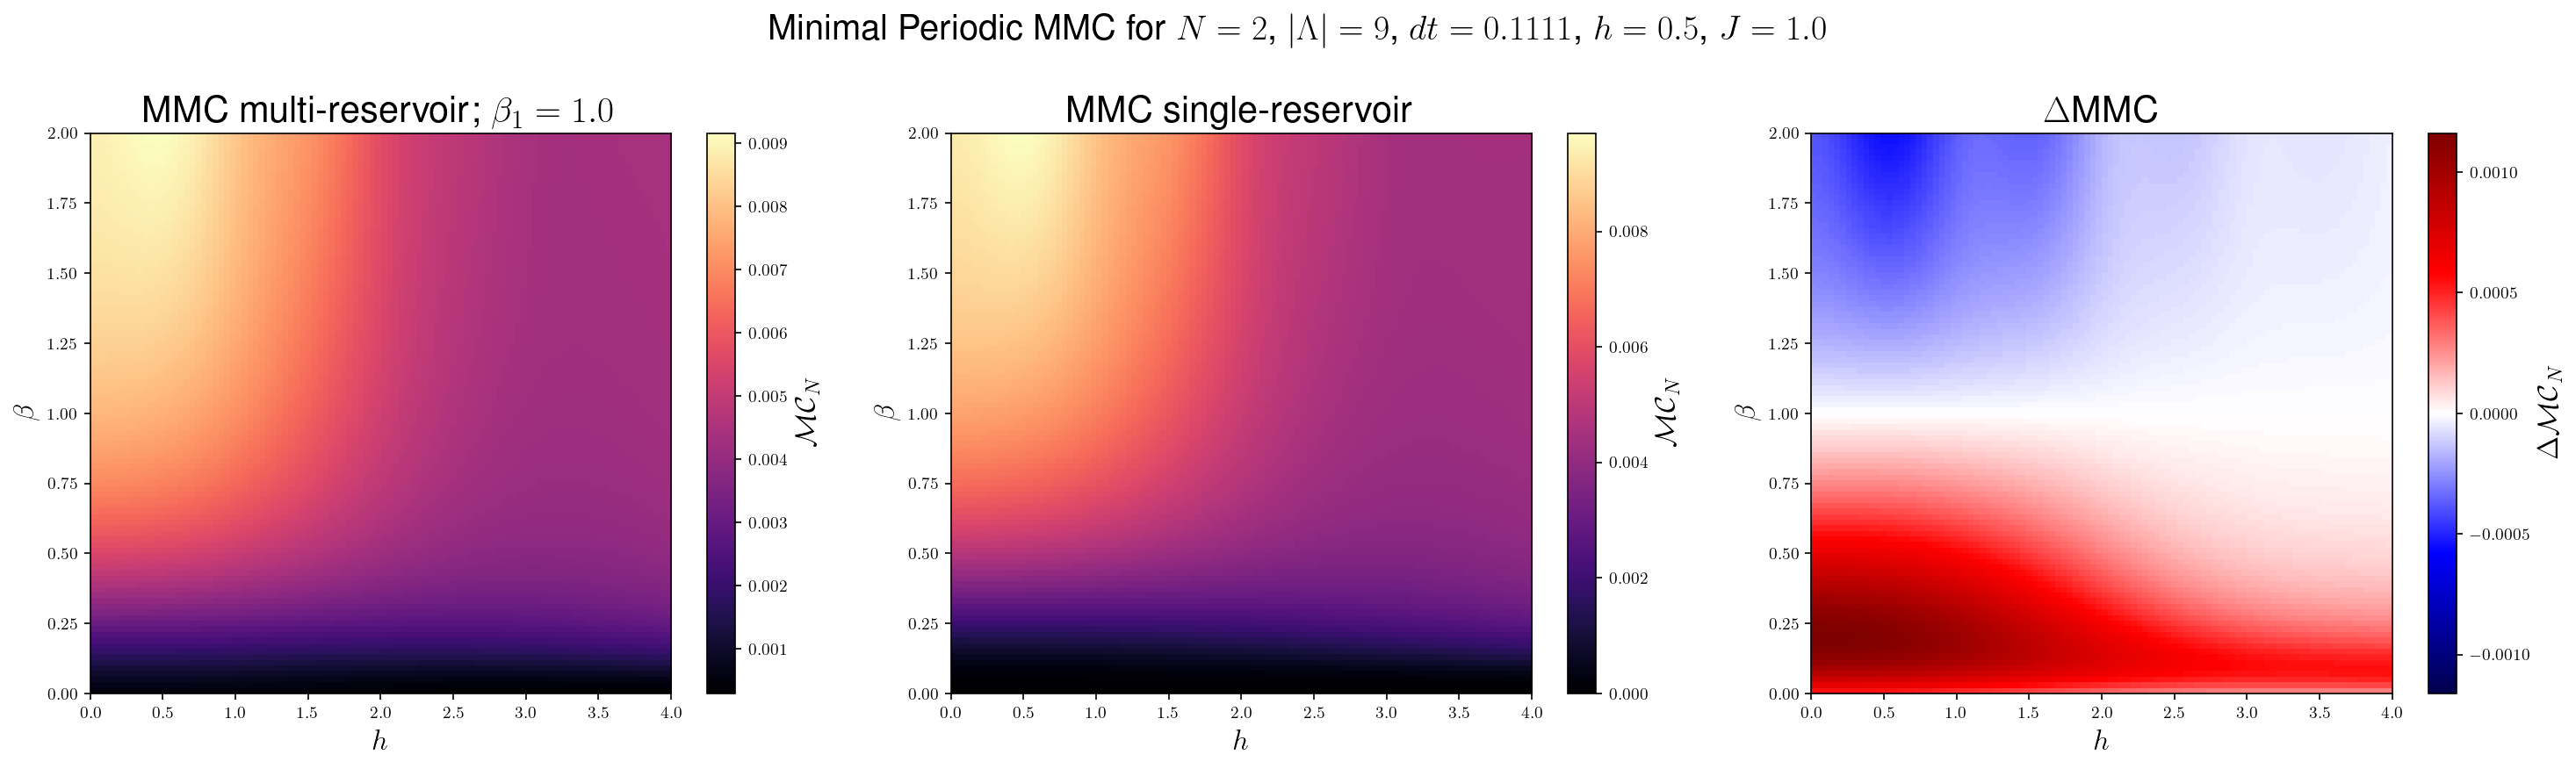

In [173]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

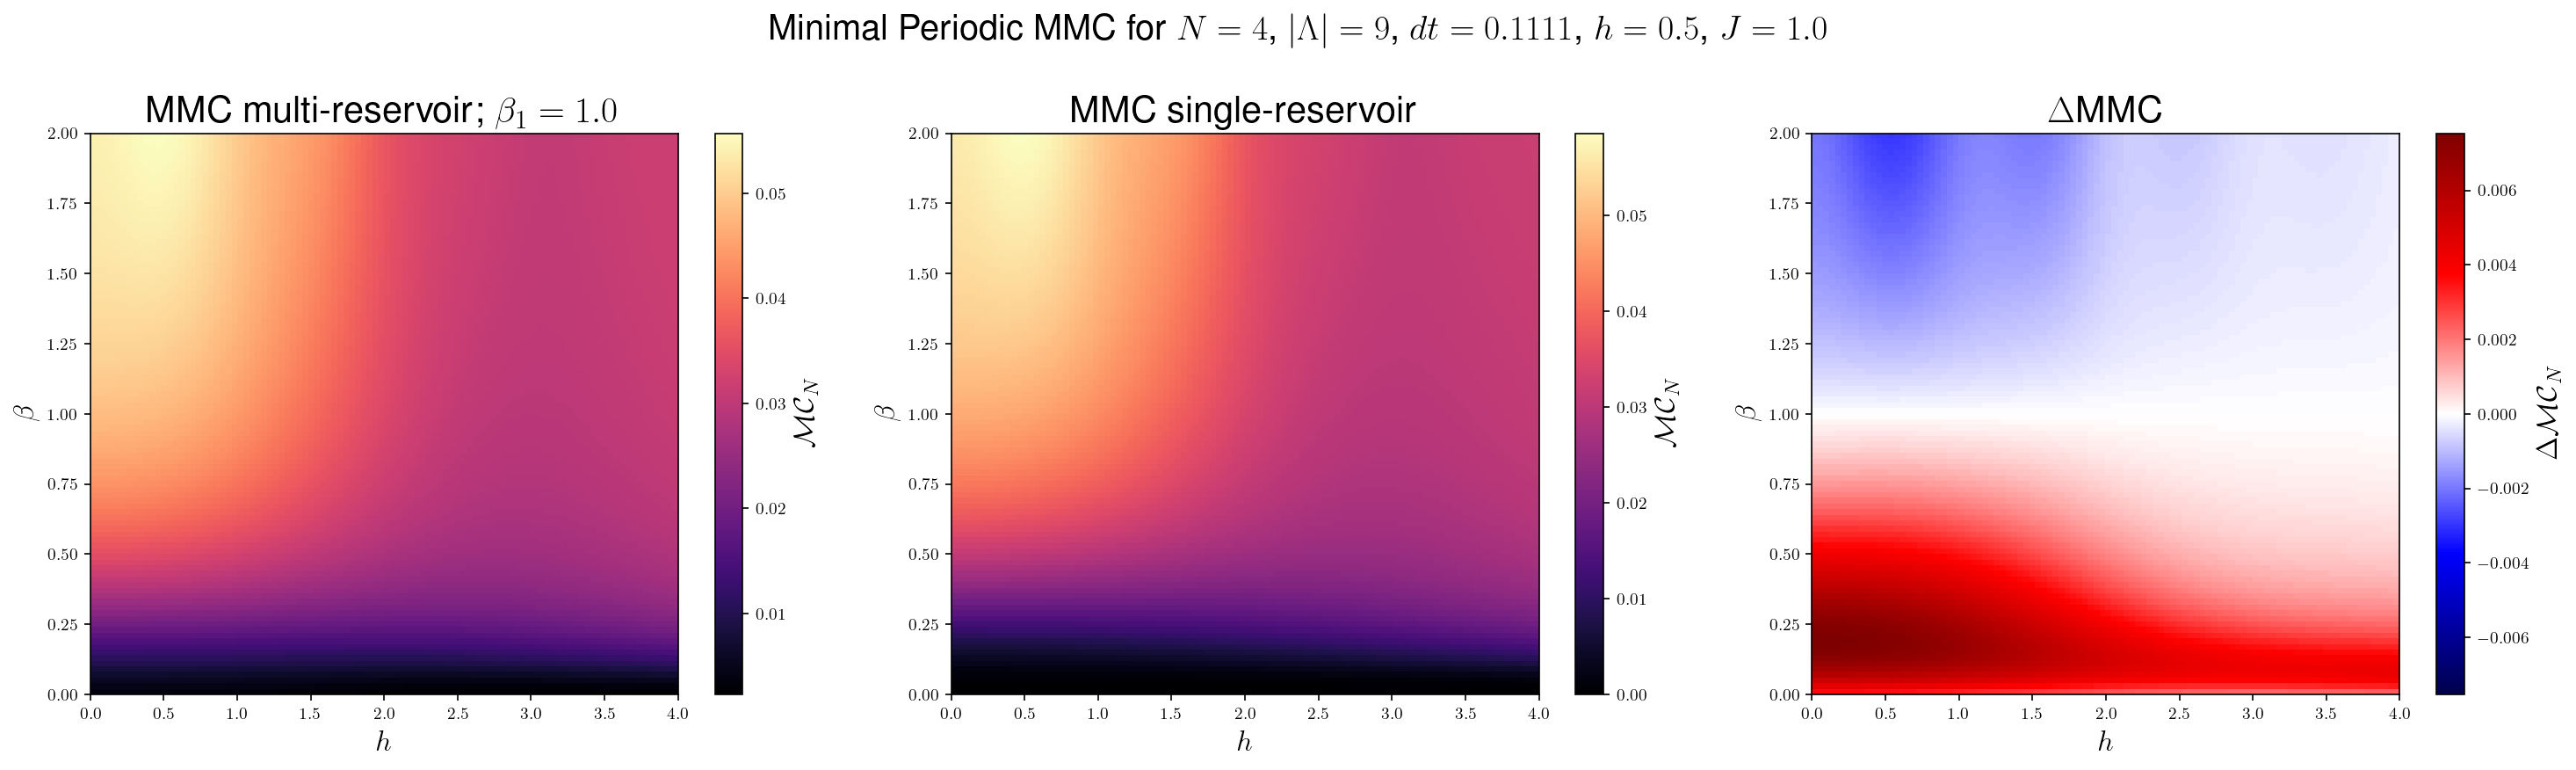

In [170]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

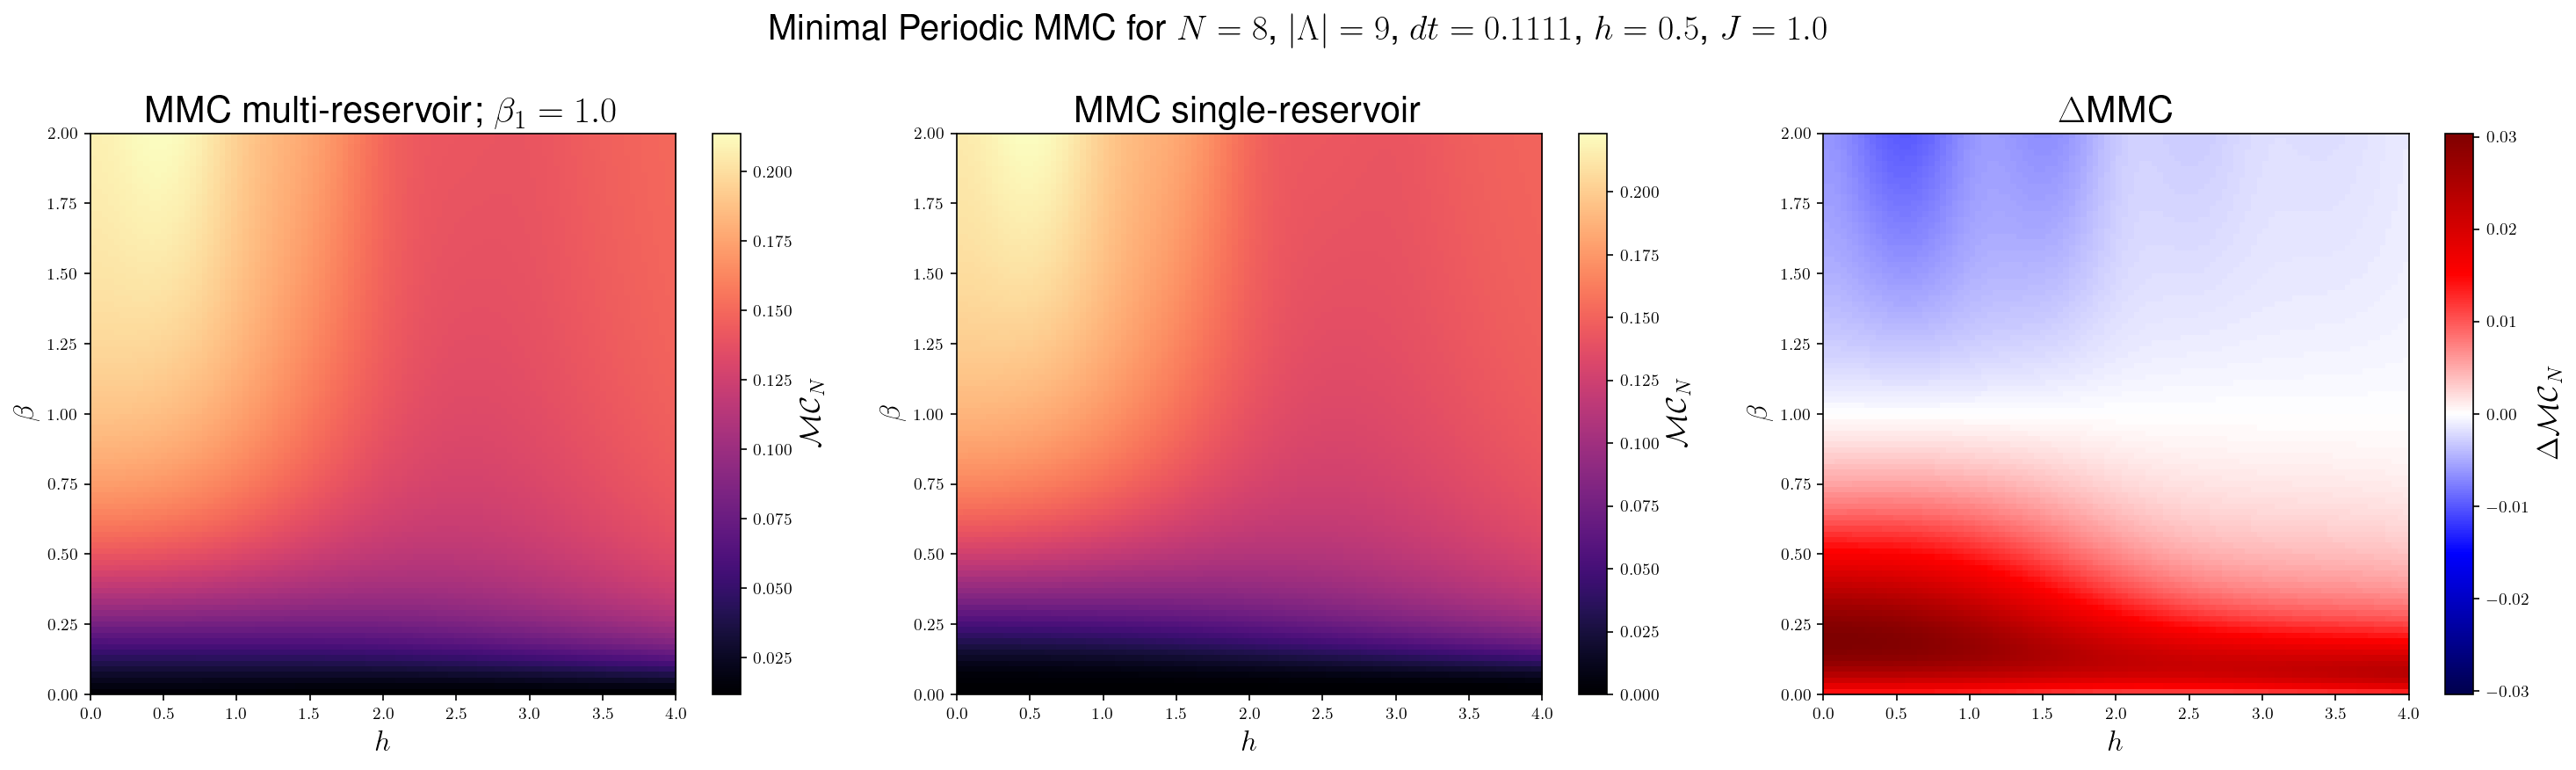

In [167]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

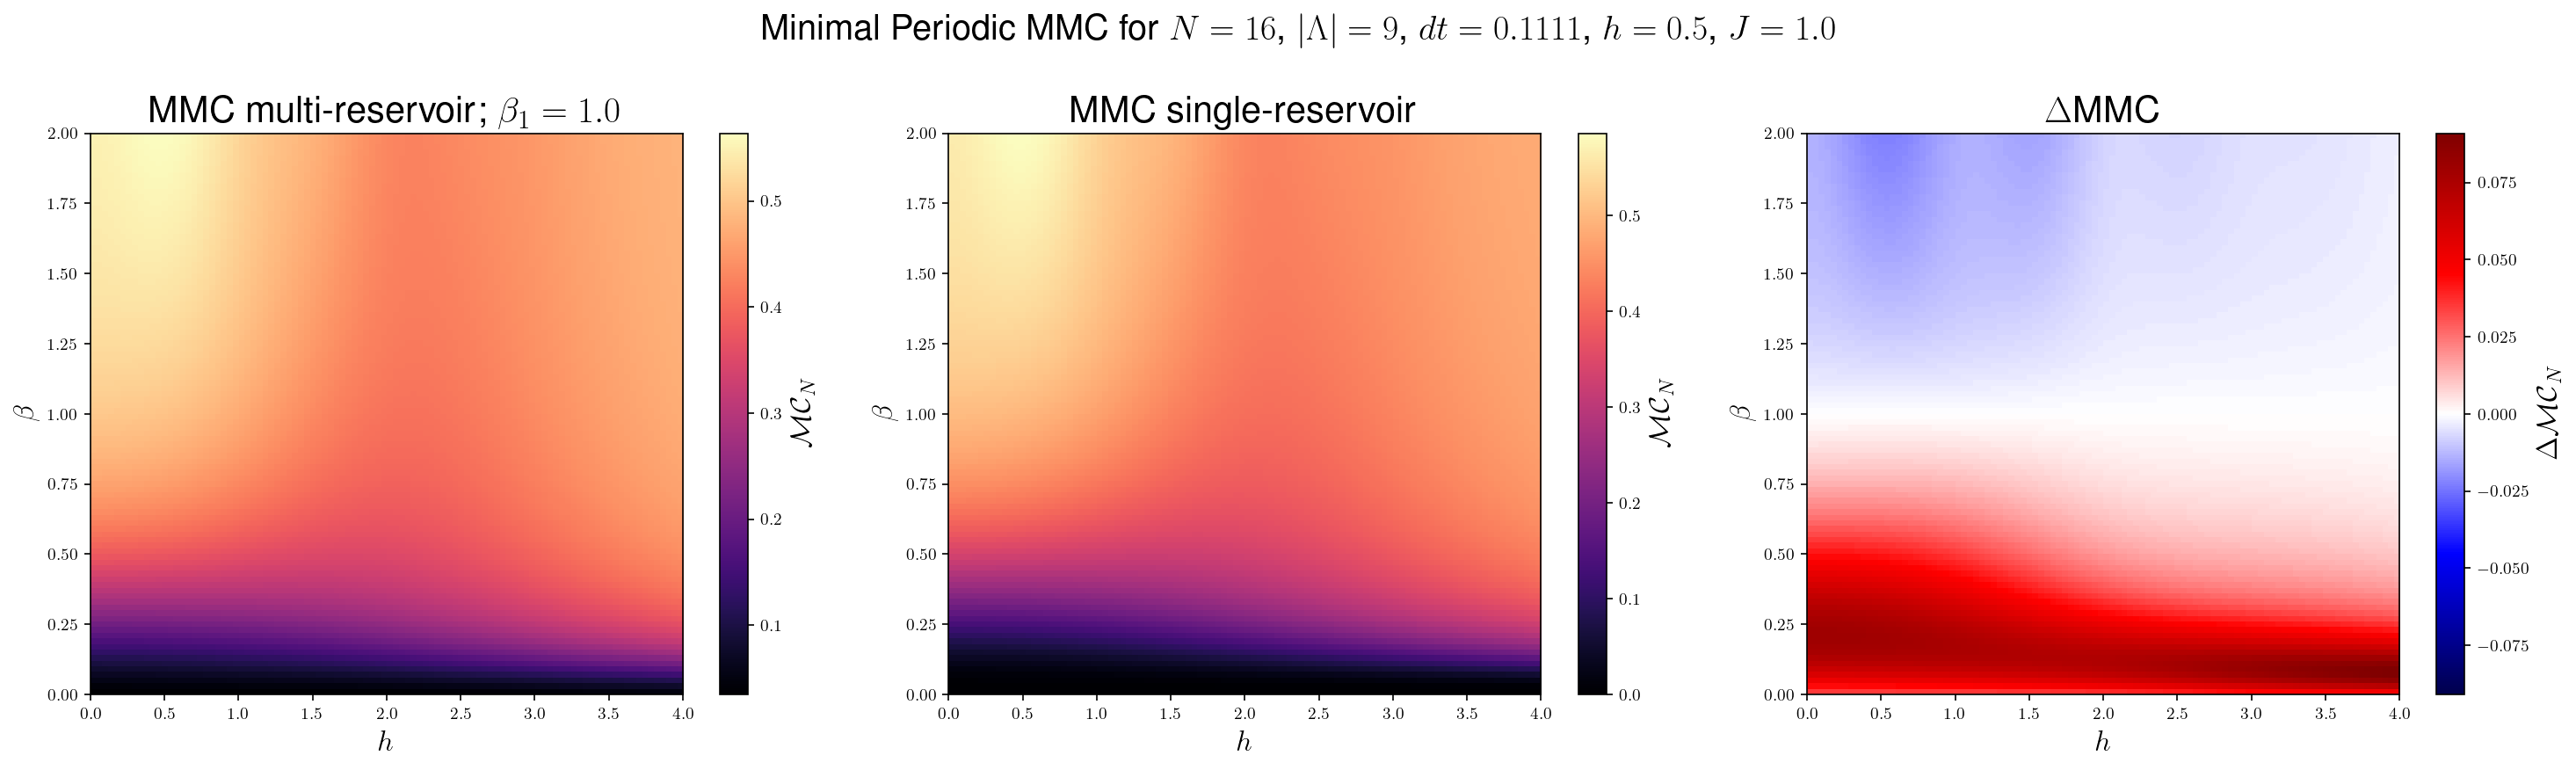

In [164]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

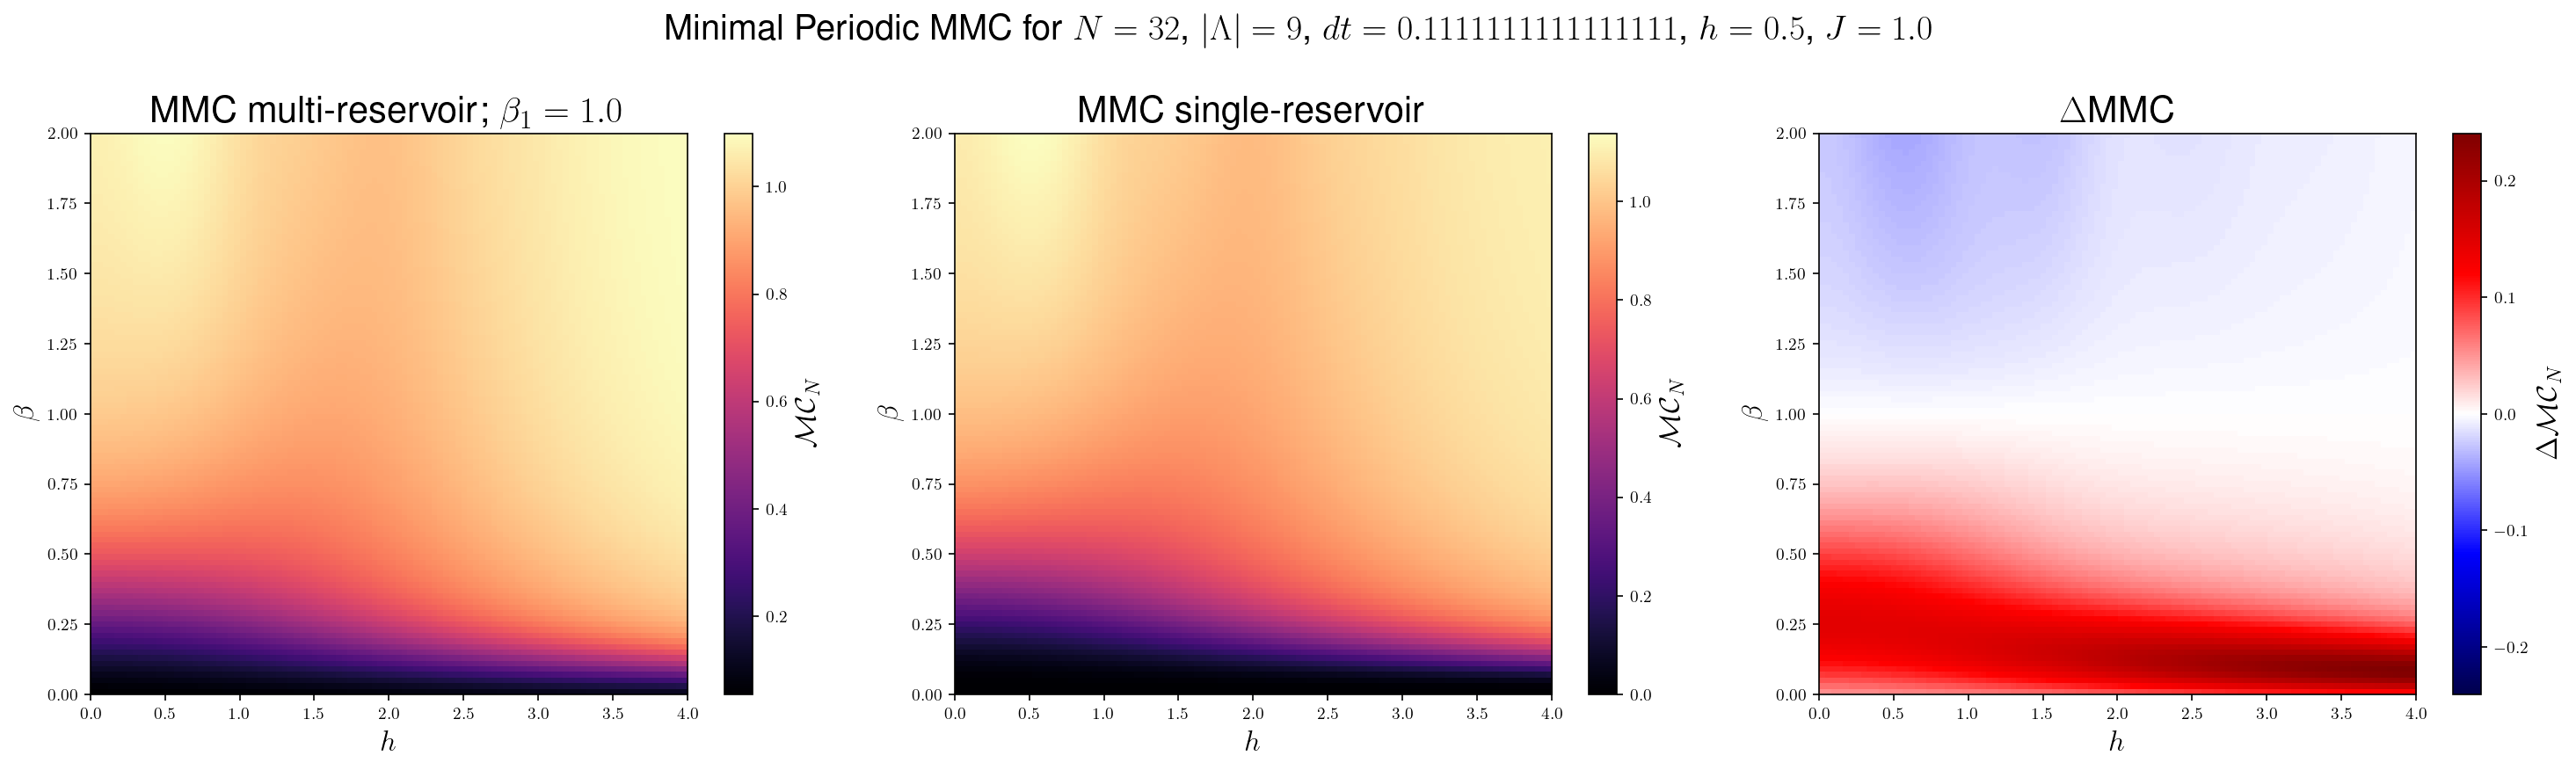

In [158]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

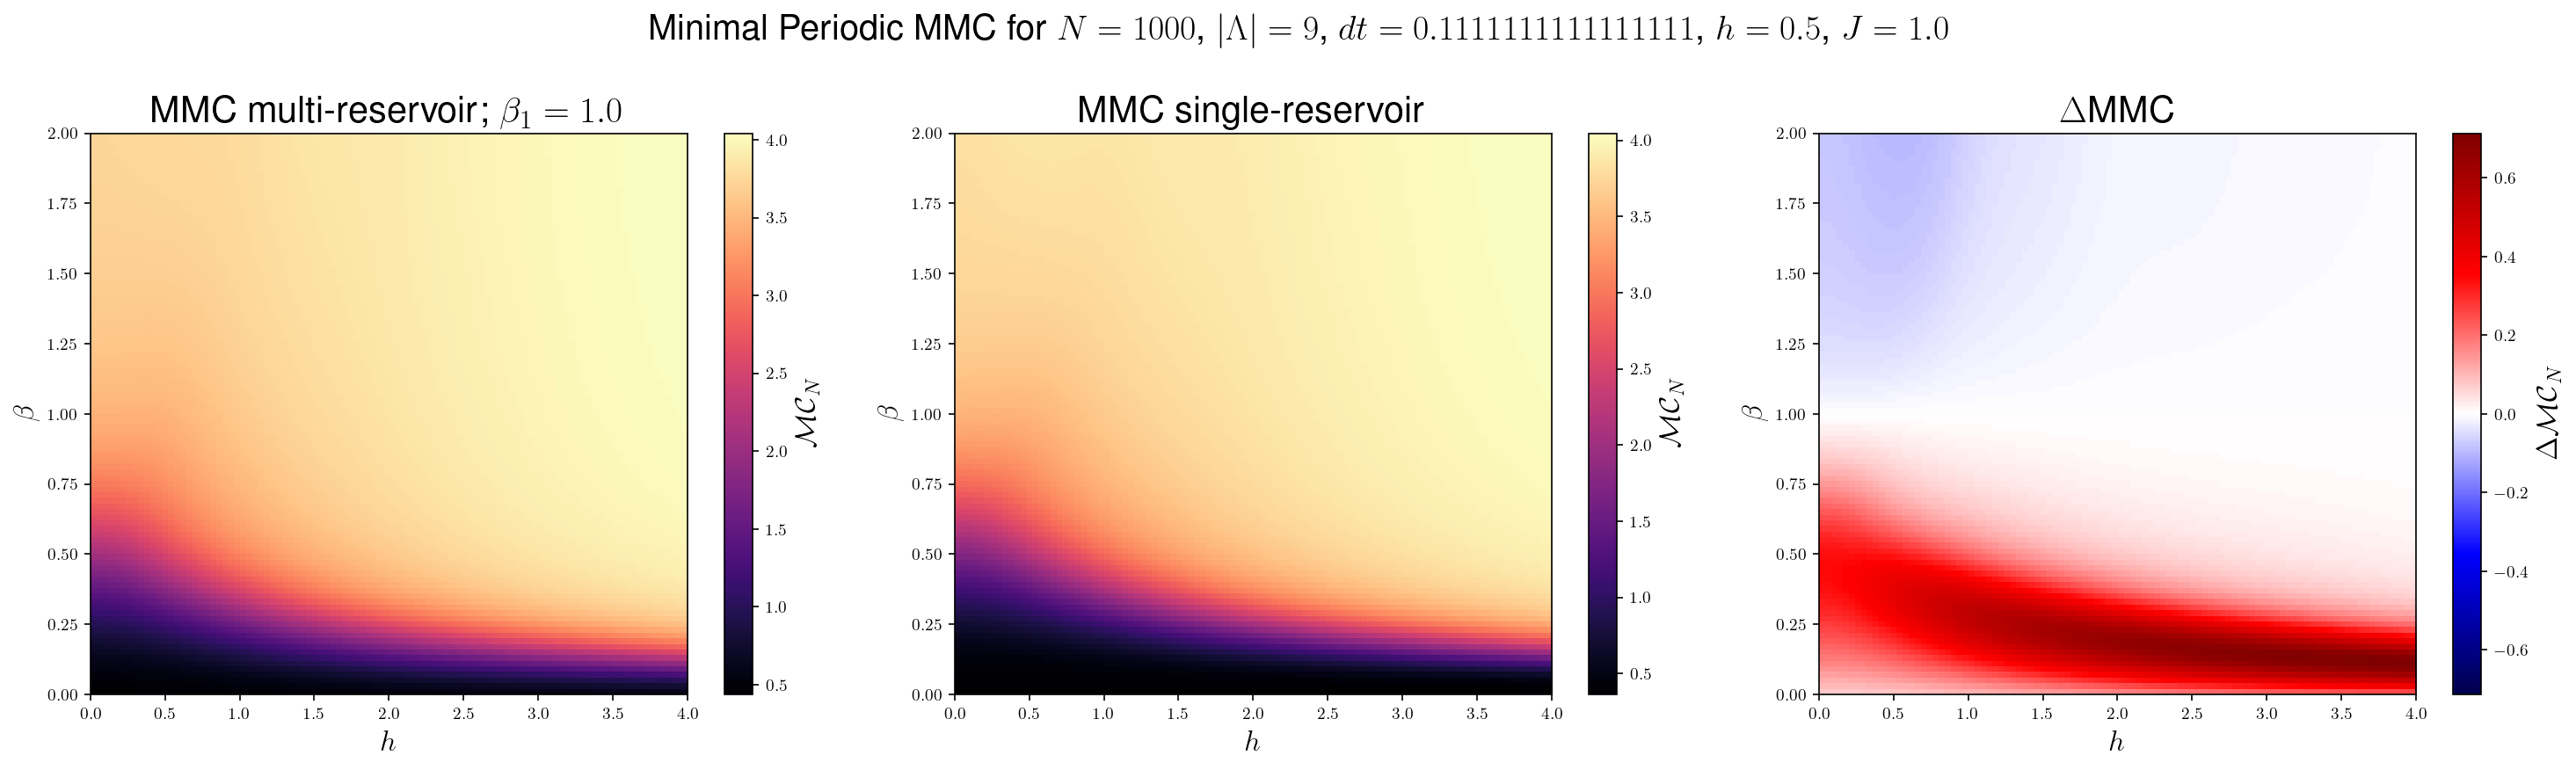

In [154]:
compare_heatmaps(heatmap, heatmap2, Nsteps, N, dt, h, J, beta1, extent, cmap='magma')

In [88]:
heatmap2 = np.asarray(eval_heatmap(params)).reshape(len(beta_vals), len(h_vals))

In [ ]:

def pmmc_eval(beta, h):
  return pmmc_kernel_old(p0, graph, beta, h, J, Nsteps)

@jax.jit
def pmmc_row(beta, h_vals):
  return lax.map(lambda h: pmmc_eval(beta, h), h_vals)

# _ = pmmc_eval(beta_vals[0], h_vals[0]).block_until_ready()  # one compile

heatmap2 = np.empty((len(beta_vals), len(h_vals)), dtype=np.float32)
for i, beta in enumerate(beta_vals):
  heatmap2[i] = np.asarray(pmmc_row(beta, h_vals))

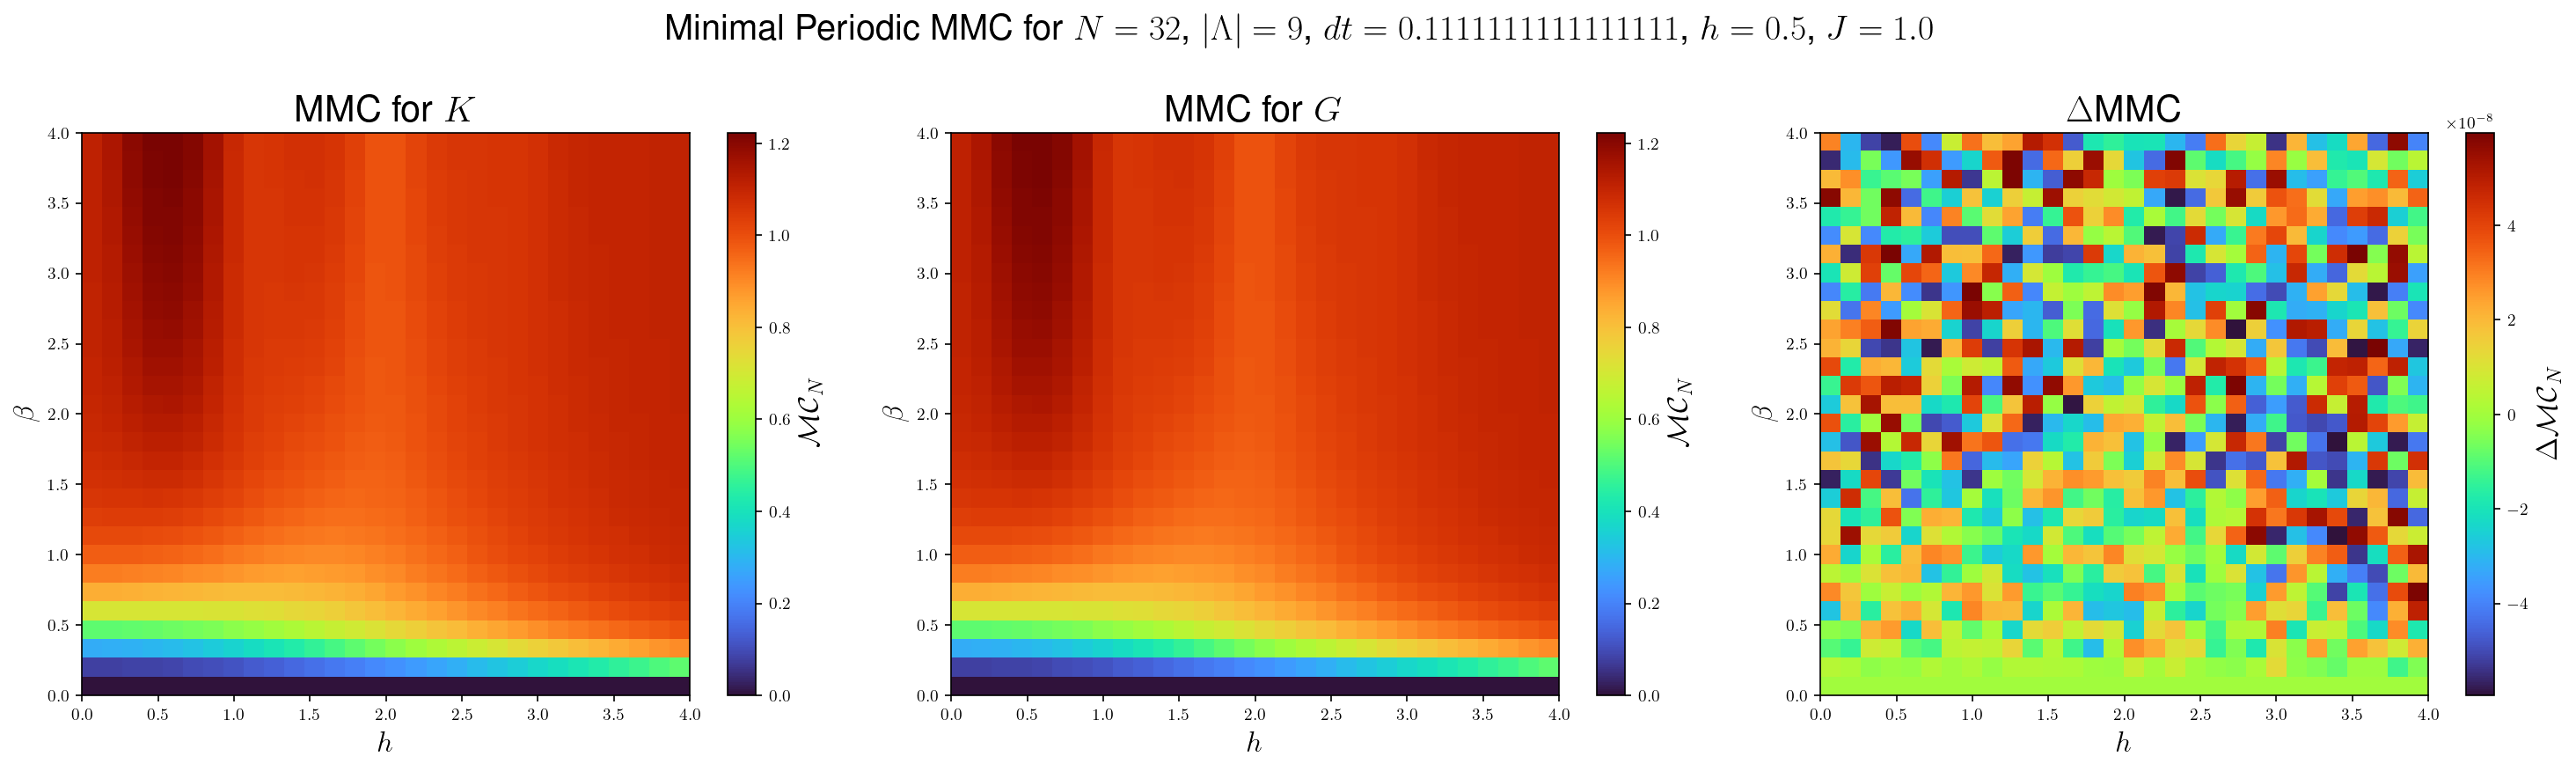

In [83]:
compare_heatmaps(heatmap, heatmap2)

In [ ]:
G = expm(K_sp * t)

In [ ]:
λ = K.sum(axis=1) + np.diag(K)

def escape_rate(i):
  return λ[i]

# τ ~ exp(λ(σ))

print(np.std(np.exp(λ)))

In [39]:
import diffrax as dfx

def make_rhs(K, g):
  n = K.shape[0]
  # State vector:
  # z = [p_1,...,p_n, Q1, Q2]
  def rhs(t, z, *args):
    p = z[:n]
    dp = K @ p
    dQ = g @ p
    return jnp.concatenate([dp, dQ])

  return dfx.ODETerm(jax.jit(rhs))

def total_ep(p0, term, tau, betas):
  n = len(p0)
  solver = dfx.Dopri5()

  z0 = np.concatenate([p0, [0.0, 0.0]])
  sol = dfx.diffeqsolve(
    term,
    solver,
    t0=0,
    t1=tau,
    dt0=0.01,
    y0=z0,
  )

  p_tau = sol.ys[-1, :n]
  Q1 = sol.ys[-1, n]
  Q2 = sol.ys[-1, n+1]
  # total EP
  Sigma = H(p_tau) - H(p0) - betas[0] * Q1 - betas[1] * Q2
  return Sigma, p_tau, Q1, Q2


def make_precomp_rhs(K: Array, tau, g):
  n = K.shape[0]
  G = jax.scipy.linalg.expm(K * tau)

  # a_nu = integral_0^tau exp(K^T t) g_nu dt
  #
  # Store a1,a2 as ROWS of A.
  
  def rhs(t, A_flat, *args):
    A = A_flat.reshape(2, n)
    # row version of da/dt = K^T a + g
    dA = A @ K + g
    return dA.ravel()
  
  return G, dfx.ODETerm(jax.jit(rhs))

def precomp_ep_cost(p0: Array, term, tau):
  n = p0.shape[0]
  solver = dfx.Dopri5()

  sol = dfx.diffeqsolve(
    term,
    solver,
    t0=0,
    t1=tau,
    dt0=0.01,
    y0=jnp.zeros((2 * n,)),
  )
  A = sol.ys[-1].reshape(2, n)
  a1 = A[0]
  a2 = A[1]
  return a1, a2


def precompute_ep(K, g, betas, tau):
  K = np.asarray(K)
  g = np.asarray(g)
  betas = np.asarray(betas)

  n_baths, n_states = g.shape
  n_tot = n_states + n_baths

  G = expm(K * tau)

  M = np.zeros((n_tot, n_tot))

  M[:n_states, :n_states] = K.T
  M[:n_states, n_states:] = g.T

  EM = expm(M * tau)

  # A[nu, :] = a_nu
  A = EM[:n_states, n_states:].T

  c = betas @ A

  return G, A, c


def EP_cost(p, G, c):
  p_tau = G @ p
  return H(p_tau) - H(p) - c @ p

/var/folders/fr/n59gclp95830bd9kqj0dy7hr0000gn/T/ipykernel_64556/1962989454.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  betas_this = jnp.array([1/T1, 1/T])


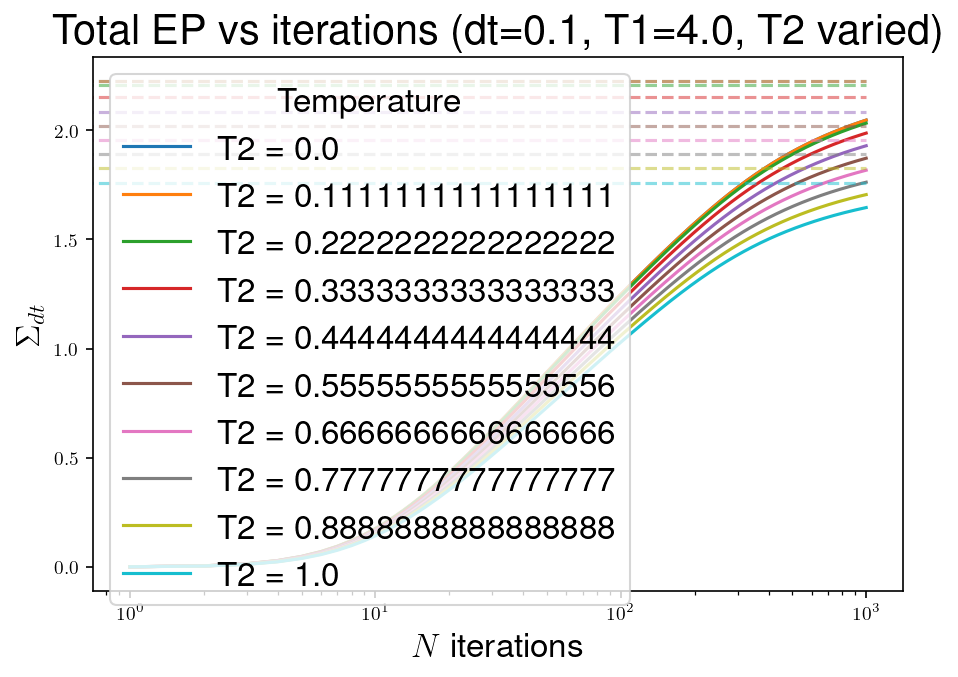

In [130]:
# ── Parameters ──────────────────────────────
dt = 0.1
N_max = 1000

fig, ax = plt.subplots(1, 1, squeeze=True)

# unjitted, and constructing this function in the T loop, it is much slower than just a 
# for loop with a numpy array. However, jitted beforehand, it is much faster -> 2-3 orders of magnitude faster
@partial(jax.jit, static_argnames=("N_max",))
def get_traj(G, p0, N_max):
  # p <- G @ p
  def traj(p, x):
    return G @ p, p # one mat-vec per step, not mat-mat
  pN, pts = lax.scan(traj, init=p0, length=N_max)
  return pN, jnp.concatenate((pts, pN[None]))

for T in np.linspace(0, 1, 10):
# for T in (*range(1, 9), 100):
  betas_this = jnp.array([1/T1, 1/T])
  rates_nu = get_rates(graph, J, h, betas_this, gammas_jax)
  rates = rates_nu.sum(0)
  rows, dE_J, dE_h_sign = graph
  dE = J * dE_J + h * dE_h_sign
  g = heat_rate_vectors(rates_nu, dE)
  K = dense_generator_from_rates(graph[0], rates)

  # ── Propagator and time evolution ─────────────
  propagator = make_propagator(K)

  G  = jnp.array(propagator(dt))

  # p <- G @ p
  # precompute all p_t = G^t @ p0 as a matrix — one pass
  pN, pts = get_traj(G, p0, N_max)

  # cumulative average: p_avg(N) = (1/N) Σ_{t=0}^{N-1} p_t
  cumsum = jnp.cumsum(pts[:-1], axis=0)           # shape (N_max, n_states)
  Ns     = jnp.arange(1, N_max + 1)
  p_avgs = cumsum / Ns[:, None]                  # broadcasting


  Gp_avgs = p_avgs @ G.T                         # G @ p_avg for each N

  # H(G^N p0) - H(p0) + N*(H(p_avg) - H(G p_avg))
  # vectorized over rows
  pmmcs = (
    H(pts[1:], axis=1) - H(p0) + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
  )

  # stationary state — null eigenvector of K
  vals, vecs = np.linalg.eig(G)
  idx = np.argmin(np.abs(vals - 1.0))    # eigenvalue closest to 1, not 0
  pi  = np.real(vecs[:, idx])
  pi  = np.clip(pi / pi.sum(), 0, None)

  kl  = KL(p0, pi)     # KL(p0 || pi) = Σ p log(p/q)
  line = ax.semilogx(Ns, pmmcs, label=f"T2 = {T}")[0]
  color = line.__dict__['_color']

  # G, rhs = make_precomp_rhs(K, dt, g)
  # a1, a2 = precomp_ep_cost(p0, rhs, dt)
  # c = betas_jax[0] * a1 + betas_jax[1] * a2
  # Sigma = EP_cost(p0, G, c)
  # plt.hlines(y=Sigma, xmin = 0, xmax = Ns[-1], color = 'red', linestyles='dashed')

  G, A, c = precompute_ep(
    K, g, betas_this, dt
  )
  total_eps = H(pts[1:], axis=1) - H(p0) - Ns * (p_avgs @ c)

  # single-step EP
  # Sigma = EP_cost(p0, G, c)
  # ax.hlines(y=Sigma, xmin = 0, xmax = Ns[-1], color = color, linestyles='solid', alpha=0.5)
  # line = ax.semilogx(Ns, total_eps, label=f"T2 = {T}")[0]
  # color = line.__dict__['_color']

  
  ax.hlines(y=kl, xmin = 0, xmax = Ns[-1], color = color, linestyles='--', alpha=0.5)


# ax.set(xlabel=r"$N$ iterations", ylabel=r"$\mathcal{MC}_N$")
ax.set(xlabel=r"$N$ iterations", ylabel=r"$\Sigma_{dt}$")
ax.set_title(f"Total EP vs iterations  (dt={dt}, T1={T1}, T2 varied)")
ax.legend(title="Temperature")
# ax.set_yscale('log')
plt.tight_layout()


$$
\dot Q_\nu(\sigma) = \sum_i k_i^\nu(\sigma)\Delta E_i(\sigma)
$$

In [ ]:
rates_nu, rates, dE = get_rates(
  graph, J, h, betas_jax, gammas_jax
)

# (n_baths, n_states)
g = heat_rate_vectors(rates_nu, dE)

# Qdot = g @ p

In [ ]:
rows, dE_J, dE_h_sign = graph
dE = J * dE_J + h * dE_h_sign

energies = energy_vector(graph, J, h)
energy_diff = energies[rows] - energies[None, :]
assert jnp.allclose(energy_diff, dE)

Because $T_1=T_2=T$,
$$
Q_1+Q_2=\langle E\rangle_{\tau} - \langle E\rangle_{0}
$$
$$
\Sigma_\tau = S(p_\tau) - S(p_0) - \beta (\langle E\rangle_{\tau} - \langle E\rangle_{0})
$$
because $\pi\propto e^{-\beta E}$,
$$
\Sigma_\tau(p_0) = D(p_0\|\pi) - D(p_\tau \| \pi)
$$
and because $\Sigma_{res}=0$, this is equal to mismatch cost.

$$
d/dt x = Ax + b \implies x(t) = e^{At}x(0) + \int_0^t e^{A(t-s)}b\,ds
$$

Let
$$
a_\nu = \int_0^\tau e^{K^\top t} g_\nu \,dt
$$
so
$$
Q_\nu = a_{\nu}^\top p_0
$$

In [ ]:
tau = 1.0

p0 = np.ones(n_states) / n_states

rhs = make_rhs(K, g)
Sigma, p_tau, Q1, Q2 = total_ep(
    p0, rhs, tau, betas_jax
)

print("Q1 =", Q1)
print("Q2 =", Q2)
print("Total EP =", Sigma)


G, rhs = make_precomp_rhs(K, tau, g)
a1, a2 = precomp_ep_cost(p0, rhs, tau)
c = betas_jax[0] * a1 + betas_jax[1] * a2
Sigma = EP_cost(p0, G, c)
print(Sigma)


In [ ]:
from scipy.optimize import minimize
from scipy.special import softmax
from scipy.special import logsumexp

def find_optimal_prior(G, c, tol=1e-13, maxiter=10000, damping=0.5):
  G = np.asarray(G)
  c = np.asarray(c)

  n = G.shape[0]
  q = np.ones(n) / n

  for it in range(maxiter):
    Gq = G @ q


    # KKT fixed-point equation:
    # q* ∝ exp(c + G^T log(G q*))
    z = c + G.T @ np.log(Gq)

    q_fp = softmax(z)

    # damping improves stability
    q_new = (1.0 - damping) * q + damping * q_fp


    if np.linalg.norm(q_new - q, ord=1) < tol:
      q = q_new
      break

    q = q_new

  # Check the actual KKT condition
  grad = np.log(q) - G.T @ np.log(G @ q) - c

  # At optimum grad must be constant across states
  lagrange = q @ grad
  kkt = np.max(np.abs(grad - lagrange))

  residual_EP = float(EP_cost(q, G, c))

  return q, residual_EP, {
    "iterations": it + 1,
    "kkt_residual": kkt,
    "converged": kkt < 1e-8,
  }

In [ ]:
q_star, residual_EP, info = find_optimal_prior(G, c)

print("residual EP =", residual_EP)
print("KKT residual =", info["kkt_residual"])
print("iterations =", info["iterations"])


In [ ]:
from scipy.special import softmax
# if T1=T2
# pi = softmax(-betas_jax[0] * energies)

# stationary state — null eigenvector of K
vals, vecs = np.linalg.eig(G)
idx = np.argmin(np.abs(vals - 1.0))    # eigenvalue closest to 1, not 0
pi  = np.real(vecs[:, idx])
pi  = np.clip(pi / pi.sum(), 0, None)

gibbs_EP = EP_cost(pi, G, c)

print("stationarity:", np.linalg.norm(K @ pi))
print("EP at Gibbs:", gibbs_EP)

p_tau = G @ p0
q_tau = G @ q_star
pi_tau = G @ pi


total_EP = EP_cost(p0, G, c)

MC_from_KL = KL(p0, q_star) - KL(p_tau, q_tau)

MC_from_EP = total_EP - residual_EP

print("Total EP =", total_EP)
print("Residual EP =", residual_EP)
print("MC from EP difference =", MC_from_EP)
print("MC from KL contraction =", MC_from_KL)
print("difference =", MC_from_EP - MC_from_KL)



MC_from_EP = total_EP - gibbs_EP

MC_from_KL = KL(p0, pi) - KL(p_tau, pi_tau)

print("MC from EP difference =", MC_from_EP)
print("MC from KL contraction =", MC_from_KL)
print("difference =", MC_from_EP - MC_from_KL)

